# EDA — AASE 2026/27
**Análise Exploratória dos Dados de Internamento Neonatal**

| Ficheiro | Descrição |
|---|---|
| `1_sinais_vitais_por_hora-1.csv` | Sinais vitais horários por episódio (SpO₂, FC, Perfusão) |
| `3_patologias_por_dia-1.csv` | Diagnósticos por episódio e dia |

Período: **janeiro – abril 2024** · **58 episódios**

## 0. Imports e configuração

In [1]:
import csv
import statistics
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

%matplotlib inline

# paleta
C = {
    "blue":   "#2a78d6",
    "orange": "#eb6834",
    "teal":   "#1baf7a",
    "yellow": "#eda100",
    "red":    "#d03b3b",
    "grey":   "#8996ae",
    "bg":     "#f4f7fc",
    "surf":   "#ffffff",
    "text":   "#0d1219",
    "text2":  "#4a5568",
}

plt.rcParams.update({
    "figure.facecolor":  C["bg"],
    "axes.facecolor":    C["surf"],
    "axes.edgecolor":    "#dce3f0",
    "axes.labelcolor":   C["text2"],
    "axes.grid":         True,
    "axes.axisbelow":    True,
    "grid.color":        "#e6eaf3",
    "grid.linewidth":    0.8,
    "xtick.color":       C["text2"],
    "ytick.color":       C["text2"],
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "font.family":       "sans-serif",
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titleweight":  "semibold",
    "axes.titlepad":     10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        110,
})

PASTA = "dados_aase_202627"
print("Pronto.")

Pronto.


## 1. Carregamento dos dados

In [2]:
def safe_float(v):
    try:
        return float(v)
    except (ValueError, TypeError):
        return None

# sinais vitais
with open(f"{PASTA}/1_sinais_vitais_por_hora-1.csv", newline="", encoding="utf-8") as f:
    sv_raw = list(csv.DictReader(f))

# patologias
with open(f"{PASTA}/3_patologias_por_dia-1.csv", newline="", encoding="utf-8") as f:
    pat_raw = list(csv.DictReader(f))

print(f"Sinais vitais: {len(sv_raw):,} registos")
print(f"Patologias:    {len(pat_raw):,} registos")
print(f"\nColunas SV:  {list(sv_raw[0].keys())}")
print(f"Colunas Pat: {list(pat_raw[0].keys())}")

Sinais vitais: 9,857 registos
Patologias:    696 registos

Colunas SV:  ['episodio', 'data', 'hora', 'sat_o2', 'puls_rate', 'perfusion']
Colunas Pat: ['episodio', 'data', 'patologia']


## 2. Limpeza e qualidade dos dados

In [3]:
sv_clean, sv_inv = [], []
for r in sv_raw:
    sat  = safe_float(r["sat_o2"])
    puls = safe_float(r["puls_rate"])
    perf = safe_float(r["perfusion"])
    hora = safe_float(r["hora"])
    ok = (
        sat  is not None and 50 <= sat  <= 100 and
        puls is not None and 50 <= puls <= 350 and
        perf is not None and 0  <= perf <= 20  and
        hora is not None and 0  <= hora <= 23
    )
    (sv_clean if ok else sv_inv).append(r)

print(f"Válidos:   {len(sv_clean):,}  ({len(sv_clean)/len(sv_raw)*100:.1f}%)")
print(f"Inválidos: {len(sv_inv):,}  ({len(sv_inv)/len(sv_raw)*100:.1f}%)")
print()

# tipos de problema
prob = Counter()
for r in sv_inv:
    sat  = safe_float(r["sat_o2"])
    puls = safe_float(r["puls_rate"])
    perf = safe_float(r["perfusion"])
    hora = safe_float(r["hora"])
    if sat  is None or sat  < 50 or sat  > 100: prob["SpO₂ fora do intervalo [50,100]"] += 1
    if puls is None or puls < 50 or puls > 350: prob["FC fora do intervalo [50,350]"] += 1
    if perf is None or perf < 0  or perf > 20:  prob["Perfusão fora do intervalo [0,20]"] += 1
    if hora is None or hora < 0  or hora > 23:  prob["Hora inválida"] += 1

for k, v in prob.most_common():
    print(f"  {k}: {v}")

Válidos:   9,615  (97.5%)
Inválidos: 242  (2.5%)

  FC fora do intervalo [50,350]: 91
  SpO₂ fora do intervalo [50,100]: 74
  Perfusão fora do intervalo [0,20]: 70
  Hora inválida: 8


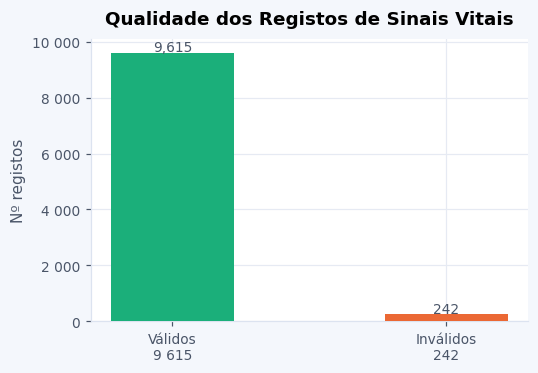

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.5))
labels = ["Válidos\n9 615", "Inválidos\n242"]
vals   = [len(sv_clean), len(sv_inv)]
colors = [C["teal"], C["orange"]]
bars = ax.bar(labels, vals, color=colors, width=0.45, zorder=3)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f"{v:,}", ha="center", fontsize=9, color=C["text2"])
ax.set_title("Qualidade dos Registos de Sinais Vitais")
ax.set_ylabel("Nº registos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}".replace(","," ")))
plt.tight_layout()
plt.show()

### 2b. Valores em falta (NaN / vazios)

In [ ]:
campos_sv  = ["episodio", "data", "hora", "sat_o2", "puls_rate", "perfusion"]
campos_pat = ["episodio", "data", "patologia"]

def conta_nulos(registos, campos):
    total = len(registos)
    res = {}
    for c in campos:
        n_vazio = sum(1 for r in registos if r.get(c, "").strip() == "")
        n_none  = sum(1 for r in registos if r.get(c) is None)
        n = n_vazio + n_none
        res[c] = (n, n / total * 100 if total else 0)
    return res, total

nan_sv,  total_sv  = conta_nulos(sv_raw,  campos_sv)
nan_pat, total_pat = conta_nulos(pat_raw, campos_pat)

print(f"Sinais Vitais ({total_sv:,} registos brutos)")
print(f"  {'Campo':<14}  {'Nulos':>6}  {'%':>6}")
for c in campos_sv:
    n, pct = nan_sv[c]
    flag = "  ⚠" if n > 0 else ""
    print(f"  {c:<14}  {n:>6}  {pct:>5.1f}%{flag}")

print(f"\nPatologias ({total_pat:,} registos brutos)")
print(f"  {'Campo':<14}  {'Nulos':>6}  {'%':>6}")
for c in campos_pat:
    n, pct = nan_pat[c]
    flag = "  ⚠" if n > 0 else ""
    print(f"  {c:<14}  {n:>6}  {pct:>5.1f}%{flag}")

# gráfico
all_items = (
    [(f"SV: {c}", *nan_sv[c])  for c in campos_sv] +
    [(f"Pat: {c}", *nan_pat[c]) for c in campos_pat]
)
labels_n = [x[0] for x in all_items]
vals_n   = [x[1] for x in all_items]
pcts_n   = [x[2] for x in all_items]
cols_n   = [C["red"] if v > 0 else C["teal"] for v in vals_n]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels_n, pcts_n, color=cols_n, width=0.6, zorder=3,
              edgecolor=C["surf"], linewidth=0.5)
ax.set_title("Percentagem de Valores em Falta por Campo",
             fontsize=12, fontweight="bold")
ax.set_ylabel("% de registos nulos")
ax.set_xticks(range(len(labels_n)))
ax.set_xticklabels(labels_n, rotation=30, ha="right", fontsize=9)
for bar, v, pct in zip(bars, vals_n, pcts_n):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, pct + 0.05,
                f"{v}\n({pct:.1f}%)", ha="center", fontsize=8, color=C["red"])
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 0.05,
                "0", ha="center", fontsize=8, color=C["teal"])
plt.tight_layout()
plt.show()

## 3. Estatísticas descritivas

In [5]:
sat_vals  = [safe_float(r["sat_o2"])    for r in sv_clean]
puls_vals = [safe_float(r["puls_rate"]) for r in sv_clean]
perf_vals = [safe_float(r["perfusion"]) for r in sv_clean]

def resumo(nome, vals, unidade=""):
    print(f"{nome}")
    print(f"  n={len(vals):,}  média={statistics.mean(vals):.2f}{unidade}  "
          f"mediana={statistics.median(vals):.2f}{unidade}  "
          f"dp={statistics.stdev(vals):.2f}  "
          f"[{min(vals):.1f}, {max(vals):.1f}]")

resumo("SpO₂",        sat_vals,  "%")
resumo("Freq. Pulso", puls_vals, " bpm")
resumo("Perfusão",    perf_vals)

print(f"\nDessaturações (SpO₂ < 90%): {sum(1 for v in sat_vals if v < 90)} "
      f"({sum(1 for v in sat_vals if v < 90)/len(sat_vals)*100:.1f}%)")

SpO₂
  n=9,615  média=95.98%  mediana=96.26%  dp=2.25  [82.2, 100.0]
Freq. Pulso
  n=9,615  média=147.74 bpm  mediana=149.41 bpm  dp=14.15  [94.8, 187.6]
Perfusão
  n=9,615  média=1.22  mediana=1.15  dp=0.45  [0.3, 5.1]

Dessaturações (SpO₂ < 90%): 119 (1.2%)


## 4. Distribuições dos sinais vitais

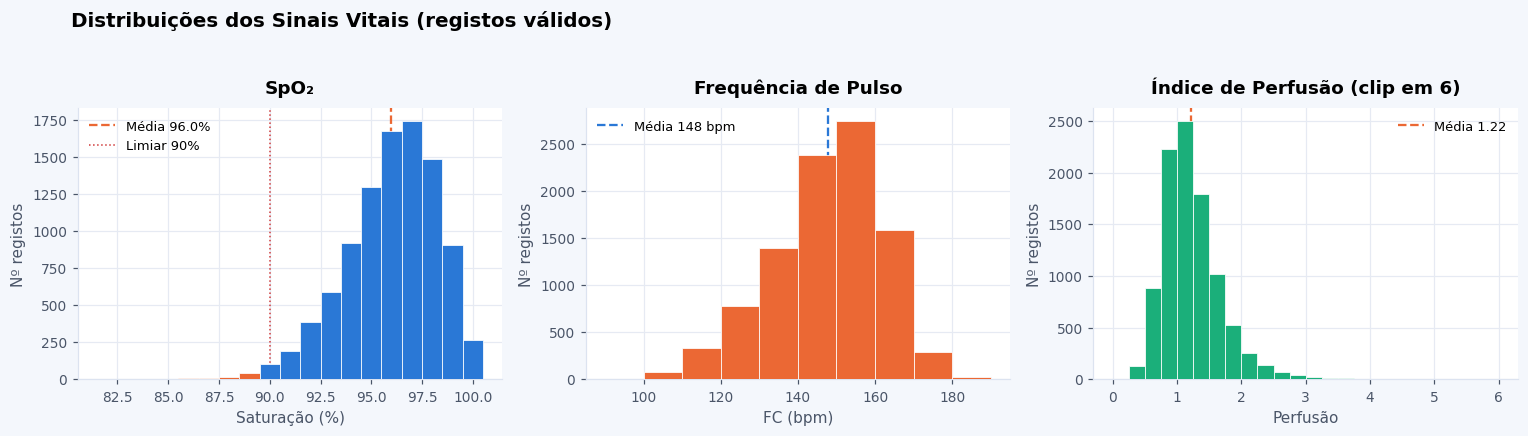

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Distribuições dos Sinais Vitais (registos válidos)",
             fontsize=13, fontweight="bold", x=0.05, ha="left")

# SpO₂
ax = axes[0]
n, bins, patches = ax.hist(sat_vals, bins=[x - 0.5 for x in range(82, 102)],
                            edgecolor=C["surf"], linewidth=0.5, zorder=3)
for patch in patches:
    patch.set_facecolor(C["orange"] if patch.get_x() + 0.5 < 90 else C["blue"])
ax.axvline(statistics.mean(sat_vals), color=C["orange"], lw=1.5, ls="--",
           label=f"Média {statistics.mean(sat_vals):.1f}%")
ax.axvline(90, color=C["red"], lw=1, ls=":", label="Limiar 90%")
ax.set_title("SpO₂")
ax.set_xlabel("Saturação (%)")
ax.set_ylabel("Nº registos")
ax.legend(fontsize=8.5, frameon=False)

# FC
ax = axes[1]
ax.hist(puls_vals, bins=range(90, 200, 10), color=C["orange"],
        edgecolor=C["surf"], linewidth=0.5, zorder=3)
ax.axvline(statistics.mean(puls_vals), color=C["blue"], lw=1.5, ls="--",
           label=f"Média {statistics.mean(puls_vals):.0f} bpm")
ax.set_title("Frequência de Pulso")
ax.set_xlabel("FC (bpm)")
ax.set_ylabel("Nº registos")
ax.legend(fontsize=8.5, frameon=False)

# Perfusão
ax = axes[2]
ax.hist([min(v, 6) for v in perf_vals], bins=np.arange(0, 6.25, 0.25),
        color=C["teal"], edgecolor=C["surf"], linewidth=0.5, zorder=3)
ax.axvline(statistics.mean(perf_vals), color=C["orange"], lw=1.5, ls="--",
           label=f"Média {statistics.mean(perf_vals):.2f}")
ax.set_title("Índice de Perfusão (clip em 6)")
ax.set_xlabel("Perfusão")
ax.set_ylabel("Nº registos")
ax.legend(fontsize=8.5, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 5. Padrão circadiano (médias por hora)

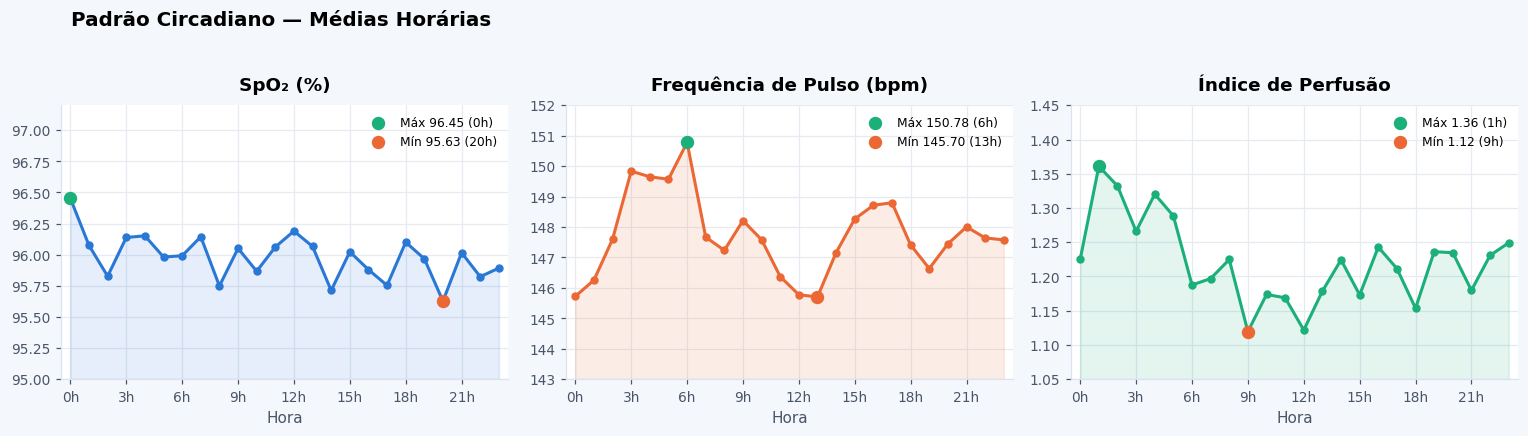

In [7]:
horas = list(range(24))
medias = {}
for h in horas:
    recs = [r for r in sv_clean if int(safe_float(r["hora"])) == h]
    medias[h] = {
        "sat":  statistics.mean(safe_float(r["sat_o2"])    for r in recs),
        "puls": statistics.mean(safe_float(r["puls_rate"]) for r in recs),
        "perf": statistics.mean(safe_float(r["perfusion"]) for r in recs),
        "n":    len(recs),
    }

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Padrão Circadiano — Médias Horárias",
             fontsize=13, fontweight="bold", x=0.05, ha="left")

specs = [
    ("sat",  "SpO₂ (%)",              C["blue"],   (95.0, 97.2)),
    ("puls", "Frequência de Pulso (bpm)", C["orange"], (143, 152)),
    ("perf", "Índice de Perfusão",     C["teal"],   (1.05, 1.45)),
]

for ax, (key, ylabel, col, ylim) in zip(axes, specs):
    vals = [medias[h][key] for h in horas]
    ax.fill_between(horas, vals, min(ylim), alpha=0.12, color=col)
    ax.plot(horas, vals, color=col, linewidth=2, zorder=3)
    ax.scatter(horas, vals, color=col, s=20, zorder=4)
    idx_max = int(np.argmax(vals))
    idx_min = int(np.argmin(vals))
    ax.scatter([idx_max], [vals[idx_max]], color=C["teal"],   s=60, zorder=5,
               label=f"Máx {vals[idx_max]:.2f} ({idx_max}h)")
    ax.scatter([idx_min], [vals[idx_min]], color=C["orange"], s=60, zorder=5,
               label=f"Mín {vals[idx_min]:.2f} ({idx_min}h)")
    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(*ylim)
    ax.set_title(ylabel)
    ax.set_xlabel("Hora")
    ax.set_xticks([0, 3, 6, 9, 12, 15, 18, 21])
    ax.set_xticklabels([f"{h}h" for h in [0, 3, 6, 9, 12, 15, 18, 21]])
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 6. Patologias

In [8]:
MAPA_PAT = {
    "doenca das membranas hialinas":  "Doença das Membranas Hialinas",
    "doença das membranas hialinas": "Doença das Membranas Hialinas",
    "dmh":                           "Doença das Membranas Hialinas",
    "icterícia neonatal":             "Icterícia Neonatal",
    "ictericia neonatal":             "Icterícia Neonatal",
    "anemia":                         "Anemia",
    "citomegalovírus":                "Citomegalovírus",
    "citomegalovirus":                "Citomegalovírus",
    "cmv":                            "Citomegalovírus",
    "displasia broncopulmonar":       "Displasia Broncopulmonar",
    "persistência do canal arterial": "Persistência do Canal Arterial",
    "refluxo gastroesofágico":        "Refluxo Gastroesofágico",
    "sépsis":                         "Sépsis",
    "lesão renal aguda":              "Lesão Renal Aguda",
    "retinopatia da prematuridade":   "Retinopatia da Prematuridade",
}

def norm_pat(p):
    return MAPA_PAT.get(p.strip().lower(), p.strip().title())

pat_norm = Counter(norm_pat(r["patologia"]) for r in pat_raw if r["patologia"].strip())
top = pat_norm.most_common(12)

print(f"Patologias distintas (após normalização): {len(pat_norm)}")
print()
for nome, cnt in top:
    print(f"  {cnt:3d}  {nome}")

Patologias distintas (após normalização): 14

  286  Doença das Membranas Hialinas
  167  Icterícia Neonatal
   56  Anemia
   51  Citomegalovírus
   38  Displasia Broncopulmonar
   32  Persistência do Canal Arterial
   26  Refluxo Gastroesofágico
   18  Sépsis
    3  Lesão Renal Aguda
    2  Retinopatia da Prematuridade
    2  Icterícia
    1  Rge


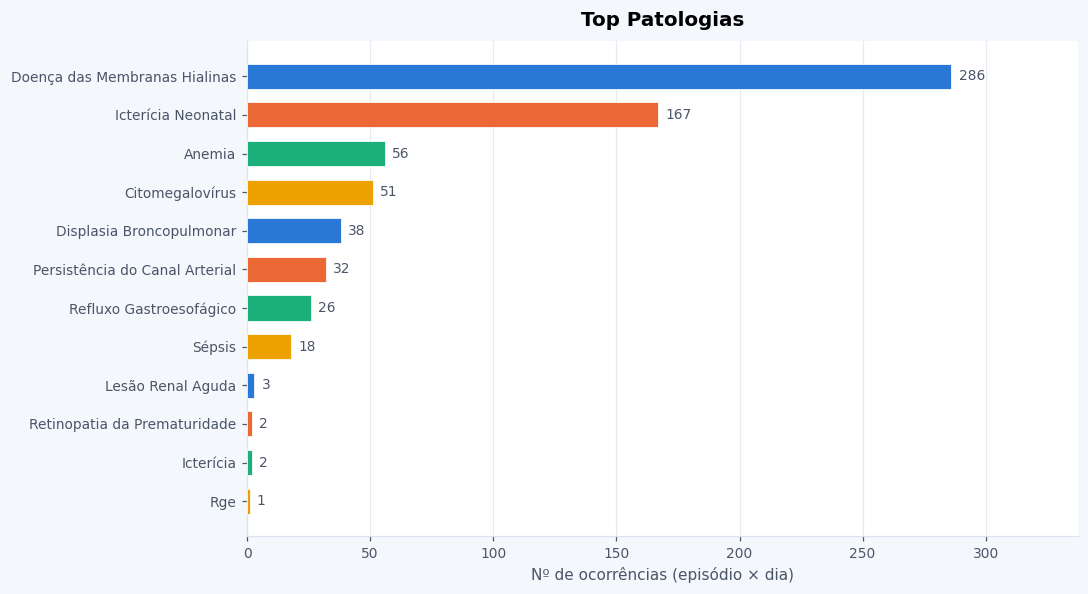

In [9]:
nomes  = [n for n, _ in top]
counts = [c for _, c in top]
cores  = [C["blue"], C["orange"], C["teal"], C["yellow"]] * 3

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(range(len(nomes)), counts, color=cores,
               height=0.65, zorder=3, edgecolor=C["surf"], linewidth=0.5)
ax.set_yticks(range(len(nomes)))
ax.set_yticklabels(nomes)
ax.invert_yaxis()
ax.set_xlabel("Nº de ocorrências (episódio × dia)")
ax.set_title("Top Patologias", fontsize=13, fontweight="bold")
ax.set_xlim(0, max(counts) * 1.18)
ax.grid(axis="y", visible=False)
for bar, v in zip(bars, counts):
    ax.text(v + 3, bar.get_y() + bar.get_height()/2,
            str(v), va="center", fontsize=9, color=C["text2"])
plt.tight_layout()
plt.show()

## 7. Episódios de internamento

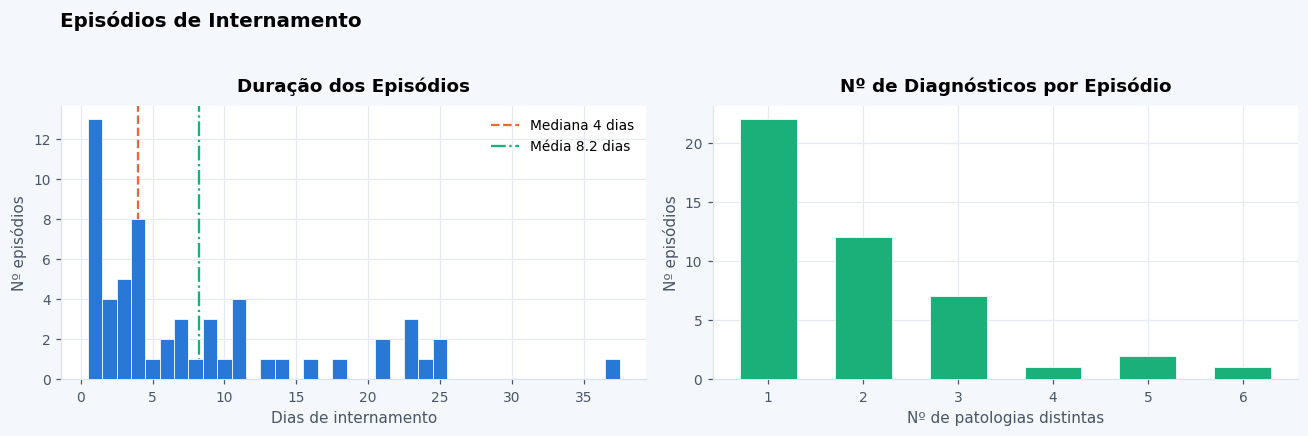

In [10]:
ep_dias = defaultdict(set)
for r in sv_clean:
    ep_dias[r["episodio"]].add(r["data"])
duracoes = sorted(len(v) for v in ep_dias.values())

ep_pats = defaultdict(set)
for r in pat_raw:
    if r["patologia"].strip():
        ep_pats[r["episodio"]].add(norm_pat(r["patologia"]))
npats = Counter(len(v) for v in ep_pats.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Episódios de Internamento",
             fontsize=13, fontweight="bold", x=0.05, ha="left")

# duração
ax = axes[0]
ax.hist(duracoes, bins=range(1, max(duracoes) + 2), color=C["blue"],
        edgecolor=C["surf"], linewidth=0.5, zorder=3, align="left")
ax.axvline(statistics.median(duracoes), color=C["orange"], lw=1.5, ls="--",
           label=f"Mediana {statistics.median(duracoes):.0f} dias")
ax.axvline(statistics.mean(duracoes), color=C["teal"], lw=1.5, ls="-.",
           label=f"Média {statistics.mean(duracoes):.1f} dias")
ax.set_title("Duração dos Episódios")
ax.set_xlabel("Dias de internamento")
ax.set_ylabel("Nº episódios")
ax.legend(fontsize=9, frameon=False)

# nº patologias
ax = axes[1]
xs = sorted(npats.keys())
ax.bar(xs, [npats[x] for x in xs], color=C["teal"],
       width=0.6, zorder=3, edgecolor=C["surf"], linewidth=0.5)
ax.set_title("Nº de Diagnósticos por Episódio")
ax.set_xlabel("Nº de patologias distintas")
ax.set_ylabel("Nº episódios")
ax.set_xticks(xs)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 8. Boxplots por episódio

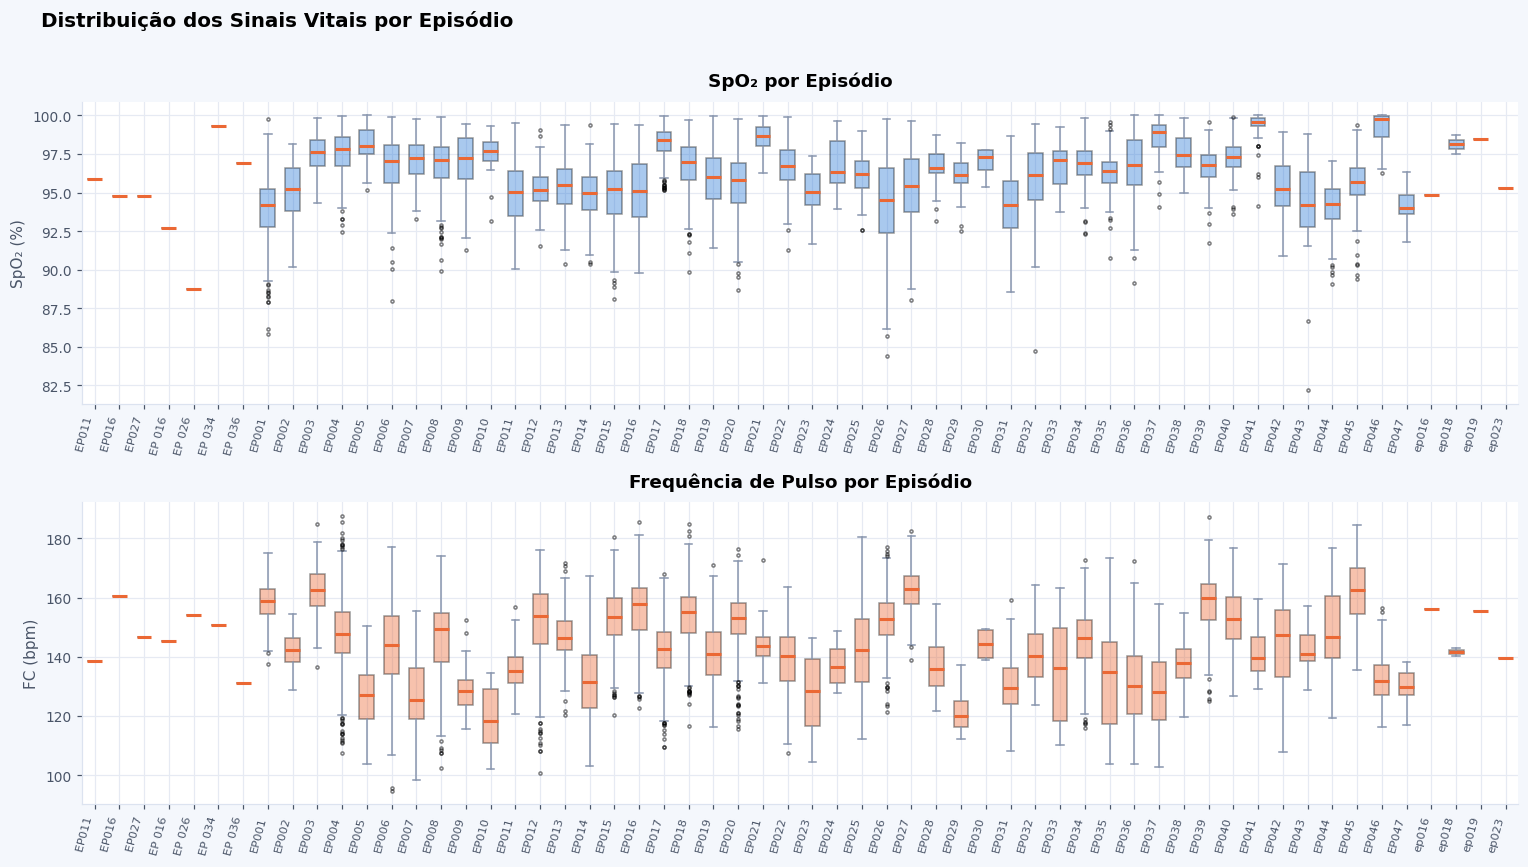

In [11]:
ep_sat  = defaultdict(list)
ep_puls = defaultdict(list)
for r in sv_clean:
    ep_sat[r["episodio"]].append(safe_float(r["sat_o2"]))
    ep_puls[r["episodio"]].append(safe_float(r["puls_rate"]))

eps       = sorted(ep_sat.keys())
sat_data  = [ep_sat[e]  for e in eps]
puls_data = [ep_puls[e] for e in eps]

bp_props = dict(
    patch_artist=True,
    medianprops=dict(color=C["orange"], linewidth=2),
    whiskerprops=dict(color=C["grey"],  linewidth=1),
    capprops=dict(color=C["grey"],      linewidth=1),
    flierprops=dict(marker="o", markersize=2, color=C["grey"], alpha=0.5),
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Distribuição dos Sinais Vitais por Episódio",
             fontsize=13, fontweight="bold", x=0.03, ha="left")

for ax, data, title, ylabel, col in [
    (axes[0], sat_data,  "SpO₂ por Episódio",                "SpO₂ (%)",  C["blue"]),
    (axes[1], puls_data, "Frequência de Pulso por Episódio", "FC (bpm)",  C["orange"]),
]:
    bplot = ax.boxplot(data, positions=range(len(eps)), widths=0.6, **bp_props)
    for patch in bplot["boxes"]:
        patch.set_facecolor(col)
        patch.set_alpha(0.4)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(eps)))
    ax.set_xticklabels(eps, rotation=75, ha="right", fontsize=7.5)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 9. Guardar figuras (opcional)

In [12]:
# Descomentar para guardar todas as figuras em graficos/
# Path("graficos").mkdir(exist_ok=True)
# for i, fig in enumerate(plt.get_fignums()):
#     plt.figure(fig).savefig(f"graficos/{i+1:02d}.png", dpi=150, bbox_inches="tight")
# print("Figuras guardadas em graficos/")

## 10. Correlações entre variáveis

In [ ]:
import math

def pearson(xs, ys):
    n = len(xs)
    mx, my = sum(xs)/n, sum(ys)/n
    num = sum((x-mx)*(y-my) for x,y in zip(xs,ys))
    den = math.sqrt(sum((x-mx)**2 for x in xs) * sum((y-my)**2 for y in ys))
    return num/den if den else 0

sat_v  = [safe_float(r["sat_o2"])    for r in sv_clean]
puls_v = [safe_float(r["puls_rate"]) for r in sv_clean]
perf_v = [safe_float(r["perfusion"]) for r in sv_clean]

pares = [
    ("SpO₂", "FC",       sat_v,  puls_v),
    ("SpO₂", "Perfusão", sat_v,  perf_v),
    ("FC",   "Perfusão", puls_v, perf_v),
]

print("Correlações de Pearson entre sinais vitais")
print(f"{'Par':<22}  r")
for lx, ly, xs, ys in pares:
    r = pearson(xs, ys)
    print(f"  {lx} × {ly:<12}  {r:+.4f}")

# scatter matrix
fig, axes = plt.subplots(3, 3, figsize=(10, 9))
fig.suptitle("Matriz de Dispersão — Sinais Vitais",
             fontsize=13, fontweight="bold", x=0.05, ha="left")

vars_info = [
    ("SpO₂ (%)",   sat_v,  C["blue"]),
    ("FC (bpm)",   puls_v, C["orange"]),
    ("Perfusão",   perf_v, C["teal"]),
]

sample_idx = list(range(0, len(sat_v), max(1, len(sat_v)//600)))

for i, (label_i, vals_i, col_i) in enumerate(vars_info):
    for j, (label_j, vals_j, col_j) in enumerate(vars_info):
        ax = axes[i][j]
        if i == j:
            ax.hist(vals_i, bins=30, color=col_i, edgecolor=C["surf"],
                    linewidth=0.4, zorder=3)
            ax.set_title(label_i, fontsize=9)
        else:
            xs_s = [vals_j[k] for k in sample_idx]
            ys_s = [vals_i[k] for k in sample_idx]
            r = pearson(vals_j, vals_i)
            ax.scatter(xs_s, ys_s, s=4, alpha=0.3,
                       color=col_j if j < i else col_i)
            ax.text(0.05, 0.92, f"r = {r:+.3f}", transform=ax.transAxes,
                    fontsize=8.5, color=C["text2"])
        if i == 2: ax.set_xlabel(label_j, fontsize=8)
        if j == 0: ax.set_ylabel(label_i, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 11. Relação patologias ↔ sinais vitais

In [ ]:
# episódios → patologias (conjunto)
ep_to_pats = defaultdict(set)
for r in pat_raw:
    if r["patologia"].strip():
        ep_to_pats[r["episodio"]].add(norm_pat(r["patologia"]))

# patologia → episódios
pat_to_eps = defaultdict(set)
for ep, pats in ep_to_pats.items():
    for p in pats:
        pat_to_eps[p].add(ep)

# sinais vitais médios por episódio
ep_stats = {}
for ep in ep_sat:
    ep_stats[ep] = {
        "sat_mean":  statistics.mean(ep_sat[ep]),
        "puls_mean": statistics.mean(ep_puls[ep]),
        "desat_n":   sum(1 for v in ep_sat[ep] if v < 90),
        "desat_pct": sum(1 for v in ep_sat[ep] if v < 90) / len(ep_sat[ep]) * 100,
    }

# top patologias com ≥ 3 episódios
TOP_PAT = [p for p, eps in sorted(pat_to_eps.items(), key=lambda x: -len(x[1]))
           if len(eps) >= 3][:10]

pat_sat   = {p: [ep_stats[e]["sat_mean"]  for e in pat_to_eps[p] if e in ep_stats] for p in TOP_PAT}
pat_puls  = {p: [ep_stats[e]["puls_mean"] for e in pat_to_eps[p] if e in ep_stats] for p in TOP_PAT}
pat_desat = {p: [ep_stats[e]["desat_pct"] for e in pat_to_eps[p] if e in ep_stats] for p in TOP_PAT}

print(f"{'Patologia':<36} {'n_ep':>4}  {'SpO₂ média':>10}  {'FC média':>8}  {'% dessat':>8}")
print("-"*72)
for p in TOP_PAT:
    n = len(pat_sat[p])
    if n == 0: continue
    print(f"  {p:<34} {n:>4}  "
          f"{statistics.mean(pat_sat[p]):>9.2f}%  "
          f"{statistics.mean(pat_puls[p]):>7.1f}  "
          f"{statistics.mean(pat_desat[p]):>7.2f}%")

# gráfico: SpO₂ média por patologia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sinais Vitais Médios por Patologia (episódios com ≥ 3 ep.)",
             fontsize=13, fontweight="bold", x=0.05, ha="left")

cores_pat = (
    [C["blue"], C["orange"], C["teal"], C["yellow"],
     C["red"],  C["grey"],  C["blue"], C["orange"],
     C["teal"], C["yellow"]]
)

for ax, data_dict, xlabel, lim, label_global in [
    (axes[0], pat_sat,  "SpO₂ média (%)",    (94, 98), "SpO₂"),
    (axes[1], pat_puls, "FC média (bpm)",     (138, 160), "FC"),
]:
    means = [statistics.mean(data_dict[p]) for p in TOP_PAT if data_dict[p]]
    pats  = [p for p in TOP_PAT if data_dict[p]]
    ns    = [len(data_dict[p]) for p in pats]
    bars  = ax.barh(range(len(pats)), means, color=cores_pat[:len(pats)],
                    height=0.6, zorder=3, edgecolor=C["surf"], linewidth=0.5)
    ax.set_yticks(range(len(pats)))
    ax.set_yticklabels([f"{p} (n={n})" for p, n in zip(pats, ns)], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(f"{label_global} por Patologia")
    ax.set_xlim(min(means)*0.995, max(means)*1.005)
    ax.grid(axis="y", visible=False)
    for bar, v in zip(bars, means):
        ax.text(v + (max(means)-min(means))*0.005,
                bar.get_y() + bar.get_height()/2,
                f"{v:.2f}", va="center", fontsize=8, color=C["text2"])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# % dessaturações por patologia
fig, ax = plt.subplots(figsize=(9, 5))
desat_means = [(p, statistics.mean(pat_desat[p])) for p in TOP_PAT if pat_desat[p]]
desat_means.sort(key=lambda x: -x[1])
pats_d, vals_d = zip(*desat_means)
cols_d = [C["red"] if v > 2 else C["blue"] for v in vals_d]
bars = ax.barh(range(len(pats_d)), vals_d, color=cols_d,
               height=0.6, zorder=3, edgecolor=C["surf"], linewidth=0.5)
ax.set_yticks(range(len(pats_d)))
ax.set_yticklabels(pats_d, fontsize=8.5)
ax.invert_yaxis()
ax.axvline(2, color=C["red"], lw=1, ls="--", label="Limiar 2%")
ax.set_xlabel("% de registos com SpO₂ < 90%")
ax.set_title("Dessaturações por Patologia", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, frameon=False)
for bar, v in zip(bars, vals_d):
    ax.text(v + 0.05, bar.get_y() + bar.get_height()/2,
            f"{v:.2f}%", va="center", fontsize=8, color=C["text2"])
plt.tight_layout()
plt.show()

## 12. Co-ocorrência de patologias

In [ ]:
from itertools import combinations

# pares de patologias no mesmo episódio
cooc = Counter()
for pats in ep_to_pats.values():
    pats_list = sorted(pats)
    for a, b in combinations(pats_list, 2):
        cooc[(a, b)] += 1

top_cooc = cooc.most_common(15)
print("Top 15 pares de patologias co-ocorrentes")
print(f"  {'Par':<55}  n episódios")
print("-"*72)
for (a, b), n in top_cooc:
    print(f"  {a} + {b:<30}  {n}")

# heatmap de co-ocorrências (top patologias)
TOP_H = TOP_PAT[:9]
n = len(TOP_H)
mat = [[0]*n for _ in range(n)]
for i, pi in enumerate(TOP_H):
    for j, pj in enumerate(TOP_H):
        if i == j:
            mat[i][j] = len(pat_to_eps[pi])
        elif i < j:
            key = tuple(sorted([pi, pj]))
            mat[i][j] = mat[j][i] = cooc.get(key, 0)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(mat, cmap="Blues", aspect="auto")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(TOP_H, rotation=40, ha="right", fontsize=8.5)
ax.set_yticklabels(TOP_H, fontsize=8.5)
ax.set_title("Co-ocorrência de Patologias (nº episódios)",
             fontsize=12, fontweight="bold")
for i in range(n):
    for j in range(n):
        v = mat[i][j]
        col = "white" if v > max(max(r) for r in mat)*0.6 else C["text"]
        ax.text(j, i, str(v), ha="center", va="center",
                fontsize=8.5, color=col, fontweight="semibold")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()

## 13. Cobertura cruzada dos datasets

In [ ]:
eps_sv  = set(r["episodio"] for r in sv_clean)
eps_pat = set(r["episodio"] for r in pat_raw if r["patologia"].strip())

so_sv   = eps_sv  - eps_pat
so_pat  = eps_pat - eps_sv
ambos   = eps_sv  & eps_pat

print("Cobertura por dataset")
print(f"  Episódios em sinais vitais:  {len(eps_sv)}")
print(f"  Episódios em patologias:     {len(eps_pat)}")
print(f"  Em ambos:                    {len(ambos)}")
print(f"  Só em sinais vitais:         {len(so_sv)}  {sorted(so_sv) if so_sv else ''}")
print(f"  Só em patologias:            {len(so_pat)} {sorted(so_pat) if so_pat else ''}")

# cobertura dia-a-dia: dias com SV mas sem patologia registada
dias_sv  = defaultdict(set)
dias_pat = defaultdict(set)
for r in sv_clean:
    dias_sv[r["episodio"]].add(r["data"])
for r in pat_raw:
    if r["patologia"].strip():
        dias_pat[r["episodio"]].add(r["data"])

lacunas_sv_sem_pat = sum(
    len(dias_sv[ep] - dias_pat.get(ep, set())) for ep in ambos
)
lacunas_pat_sem_sv = sum(
    len(dias_pat[ep] - dias_sv.get(ep, set())) for ep in ambos
)

print(f"\nDias (episódio×dia) em ambos os datasets:")
print(f"  Dias com SV mas sem patologia registada:  {lacunas_sv_sem_pat}")
print(f"  Dias com patologia mas sem SV:             {lacunas_pat_sem_sv}")

# diagrama de Venn simplificado
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Cobertura Cruzada dos Datasets",
             fontsize=13, fontweight="bold", x=0.05, ha="left")

# episódios
ax = axes[0]
counts_ep = [len(so_sv), len(ambos), len(so_pat)]
labels_ep = [f"Só SV\n{len(so_sv)}", f"Ambos\n{len(ambos)}", f"Só Pat.\n{len(so_pat)}"]
colors_ep = [C["blue"], C["teal"], C["orange"]]
bars = ax.bar(labels_ep, counts_ep, color=colors_ep, width=0.5, zorder=3,
              edgecolor=C["surf"], linewidth=0.5)
ax.set_title("Episódios por Dataset")
ax.set_ylabel("Nº episódios")
for bar, v in zip(bars, counts_ep):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(v), ha="center", fontsize=10, color=C["text2"])

# dias
ax = axes[1]
counts_d = [lacunas_sv_sem_pat, lacunas_pat_sem_sv]
labels_d = ["Dias com SV\nsem patologia", "Dias com patologia\nsem SV"]
cols_d   = [C["blue"], C["orange"]]
bars = ax.bar(labels_d, counts_d, color=cols_d, width=0.4, zorder=3,
              edgecolor=C["surf"], linewidth=0.5)
ax.set_title("Lacunas Dia × Episódio")
ax.set_ylabel("Nº de dias")
for bar, v in zip(bars, counts_d):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(v), ha="center", fontsize=10, color=C["text2"])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 14. Tendência temporal (Janeiro–Abril 2024)

In [ ]:
from datetime import datetime

def parse_date(s):
    for fmt in ("%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y"):
        try:
            return datetime.strptime(s.strip(), fmt)
        except ValueError:
            pass
    return None

# agregar por mês
mes_sv   = defaultdict(list)   # mês → [sat_o2]
mes_fc   = defaultdict(list)
mes_recs = defaultdict(int)
mes_eps  = defaultdict(set)

for r in sv_clean:
    d = parse_date(r["data"])
    if not d:
        continue
    key = (d.year, d.month)
    mes_sv[key].append(safe_float(r["sat_o2"]))
    mes_fc[key].append(safe_float(r["puls_rate"]))
    mes_recs[key] += 1
    mes_eps[key].add(r["episodio"])

meses = sorted(mes_sv.keys())
rotulos = [f"{m:02d}/{y}" for y, m in meses]

sat_mens  = [statistics.mean(mes_sv[k])   for k in meses]
fc_mens   = [statistics.mean(mes_fc[k])   for k in meses]
recs_mens = [mes_recs[k]                   for k in meses]
eps_mens  = [len(mes_eps[k])               for k in meses]

# episódios novos por mês (primeira ocorrência)
ep_primeiro_mes = {}
for r in sv_clean:
    d = parse_date(r["data"])
    if not d:
        continue
    key = (d.year, d.month)
    ep = r["episodio"]
    if ep not in ep_primeiro_mes or key < ep_primeiro_mes[ep]:
        ep_primeiro_mes[ep] = key

novos_mes = Counter(ep_primeiro_mes.values())

print("Resumo mensal")
print(f"  {'Mês':<8}  {'Registos':>8}  {'Episódios':>9}  {'Novos':>6}  "
      f"{'SpO₂ média':>10}  {'FC média':>8}")
print("-"*60)
for k, rot in zip(meses, rotulos):
    print(f"  {rot:<8}  {mes_recs[k]:>8,}  {len(mes_eps[k]):>9}  "
          f"{novos_mes.get(k,0):>6}  "
          f"{statistics.mean(mes_sv[k]):>9.2f}%  "
          f"{statistics.mean(mes_fc[k]):>7.1f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Tendência Temporal — Janeiro a Abril 2024",
             fontsize=13, fontweight="bold", x=0.05, ha="left")

xs = range(len(meses))

for ax, vals, title, ylabel, col in [
    (axes[0][0], recs_mens,  "Volume de Registos por Mês",       "Nº registos",    C["blue"]),
    (axes[0][1], eps_mens,   "Episódios Ativos por Mês",         "Nº episódios",   C["orange"]),
    (axes[1][0], sat_mens,   "SpO₂ Média por Mês",               "SpO₂ (%)",       C["teal"]),
    (axes[1][1], fc_mens,    "FC Média por Mês",                  "FC (bpm)",       C["yellow"]),
]:
    ax.bar(xs, vals, color=col, width=0.5, zorder=3,
           edgecolor=C["surf"], linewidth=0.5, alpha=0.8)
    ax.plot(xs, vals, color=col, lw=2, marker="o", markersize=6, zorder=4)
    ax.set_xticks(list(xs))
    ax.set_xticklabels(rotulos, fontsize=9)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for x, v in zip(xs, vals):
        ax.text(x, v + (max(vals)-min(vals))*0.02 if max(vals) > min(vals) else v*0.01,
                f"{v:.1f}" if isinstance(v, float) else str(v),
                ha="center", fontsize=8.5, color=C["text2"])

# sobrepor episódios novos no gráfico de episódios ativos
ax2 = axes[0][1].twinx()
novos_vals = [novos_mes.get(k, 0) for k in meses]
ax2.plot(xs, novos_vals, color=C["red"], lw=1.5, ls="--",
         marker="s", markersize=5, label="Novos")
ax2.set_ylabel("Novos episódios", color=C["red"], fontsize=8)
ax2.tick_params(axis="y", labelcolor=C["red"], labelsize=8)
ax2.legend(loc="upper right", fontsize=8, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()